In [2]:
import glob

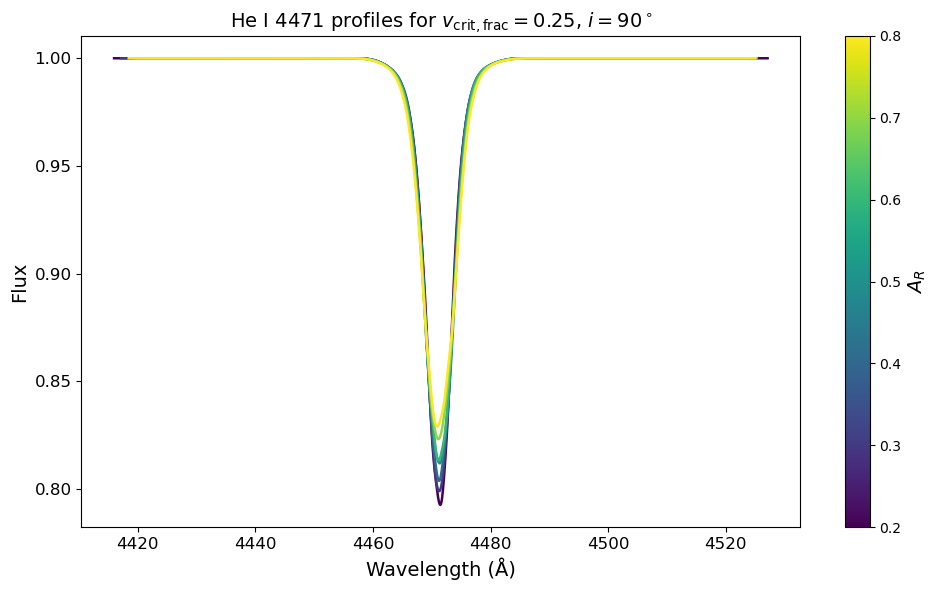

In [28]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize

base_dir = "/home/c4011027/PhD_stuff/SPAMMS/Outputs/results"

def read_model_info(filepath):
    params = {}
    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if not line or ":" not in line:
                continue
            key, val = line.split(":", 1)
            params[key.strip()] = val.strip()
    return params

def safe_float(val):
    try:
        return float(val)
    except Exception:
        return None

model_dirs = sorted(glob.glob(os.path.join(base_dir, "Model_*")))

selected_profiles = []

for model_dir in model_dirs:
    info_file = os.path.join(model_dir, "model_info.txt")
    if not os.path.isfile(info_file):
        continue

    params = read_model_info(info_file)

    vcrit = safe_float(params.get("v_crit_frac"))
    incl = safe_float(params.get("inclination"))
    A_R = safe_float(params.get("A_R"))

    if vcrit != 0.25 or incl != 90.0:
        continue

    # find the abundance/grid subfolder
    subdirs = [d for d in glob.glob(os.path.join(model_dir, "*")) if os.path.isdir(d)]
    if not subdirs:
        continue

    # assume only one such folder exists
    prof_dir = subdirs[0]

    line_file = os.path.join(prof_dir, "hjd0.00000000000_HEI4471.txt")
    if not os.path.isfile(line_file):
        continue

    data = np.loadtxt(line_file)
    wave = data[:, 0]
    flux = data[:, 1]

    selected_profiles.append((A_R, wave, flux, os.path.basename(model_dir)))

if not selected_profiles:
    print("No matching models found.")
else:
    # sort by A_R
    selected_profiles.sort(key=lambda x: x[0])

    A_R_vals = [x[0] for x in selected_profiles]
    norm = Normalize(vmin=min(A_R_vals), vmax=max(A_R_vals))
    cmap = cm.viridis

    fig, ax = plt.subplots(figsize=(10, 6))

    for A_R, wave, flux, model_name in selected_profiles:
        ax.plot(
            wave,
            flux,
            color=cmap(norm(A_R)),
            lw=1.8
        )

    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])

    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label(r"$A_R$", fontsize=14)

    ax.set_xlabel("Wavelength (Å)", fontsize=14)
    ax.set_ylabel("Flux", fontsize=14)
    ax.set_title(r"He I 4471 profiles for $v_{\rm crit,frac}=0.25$, $i=90^\circ$", fontsize=14)
    ax.tick_params(axis='both', labelsize=12)
    #ax.invert_yaxis()   # optional for absorption lines

    plt.tight_layout()
    plt.show()

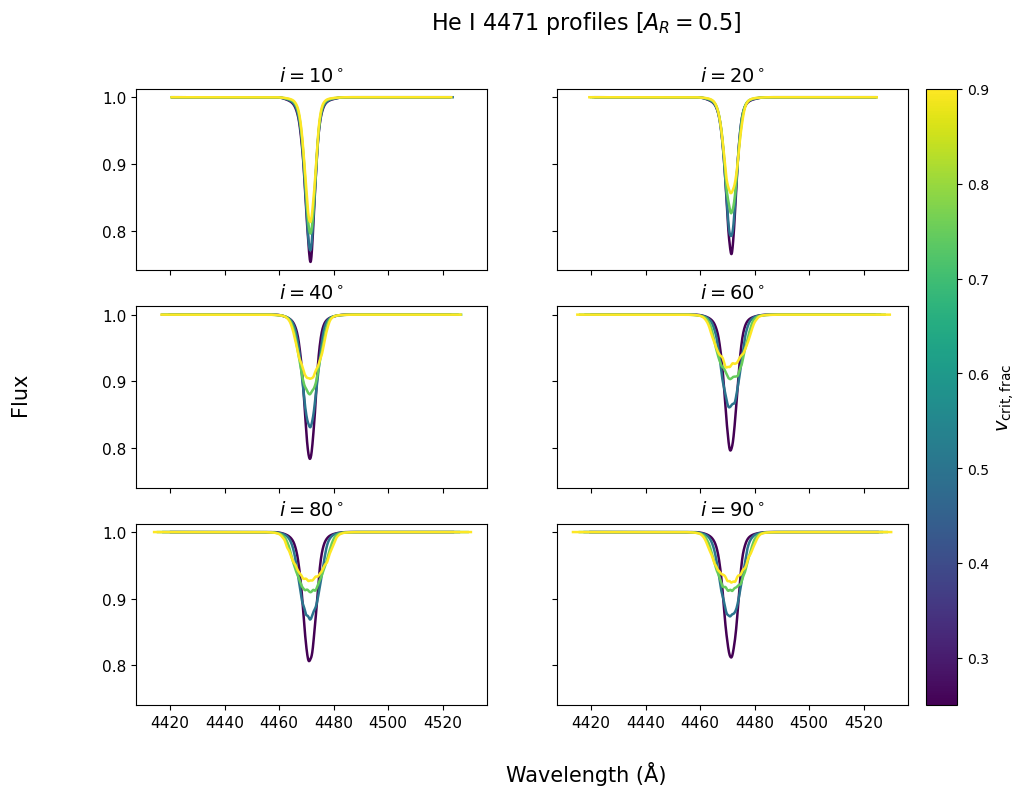

In [30]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize

base_dir = "/home/c4011027/PhD_stuff/SPAMMS/Outputs/results"

def read_model_info(filepath):
    params = {}
    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if not line or ":" not in line:
                continue
            key, val = line.split(":", 1)
            params[key.strip()] = val.strip()
    return params

def safe_float(val):
    try:
        return float(val)
    except Exception:
        return None

model_dirs = sorted(glob.glob(os.path.join(base_dir, "Model_*")))

selected_profiles = []

for model_dir in model_dirs:
    info_file = os.path.join(model_dir, "model_info.txt")
    if not os.path.isfile(info_file):
        continue

    params = read_model_info(info_file)

    A_R = safe_float(params.get("A_R"))
    incl = safe_float(params.get("inclination"))
    vcrit = safe_float(params.get("v_crit_frac"))

    if A_R is None or incl is None or vcrit is None:
        continue

    if not np.isclose(A_R, 0.5, atol=1e-6):
        continue

    subdirs = [d for d in glob.glob(os.path.join(model_dir, "*")) if os.path.isdir(d)]
    if not subdirs:
        continue

    prof_dir = subdirs[0]
    line_file = os.path.join(prof_dir, "hjd0.00000000000_HEI4471.txt")

    if not os.path.isfile(line_file):
        continue

    data = np.loadtxt(line_file)
    wave = data[:, 0]
    flux = data[:, 1]

    selected_profiles.append({
        "inclination": incl,
        "vcrit": vcrit,
        "wave": wave,
        "flux": flux,
        "model": os.path.basename(model_dir)
    })

if len(selected_profiles) == 0:
    print("No matching models found for A_R = 0.5")
else:
    inclinations = sorted(set(d["inclination"] for d in selected_profiles))
    vcrit_vals = [d["vcrit"] for d in selected_profiles]

    norm = Normalize(vmin=min(vcrit_vals), vmax=max(vcrit_vals))
    cmap = cm.viridis

    fig, axes = plt.subplots(3, 2, figsize=(12, 8), sharex=True, sharey=True)
    axes = axes.flatten()

    for ax, incl in zip(axes, inclinations):
        subset = [d for d in selected_profiles if np.isclose(d["inclination"], incl, atol=1e-6)]

        subset = sorted(subset, key=lambda x: x["vcrit"])

        for d in subset:
            ax.plot(
                d["wave"],
                d["flux"],
                color=cmap(norm(d["vcrit"])),
                lw=1.8
            )

        ax.set_title(rf"$i = {incl:.0f}^\circ$", fontsize=14)
        ax.tick_params(axis='both', labelsize=11)
        ax.invert_yaxis()

    # hide unused panels if fewer than 6 inclinations
    for j in range(len(inclinations), len(axes)):
        axes[j].axis("off")

    fig.supxlabel("Wavelength (Å)", fontsize=15)
    fig.supylabel("Flux", fontsize=15)
    fig.suptitle(r"HeI 4471 [$A_R = 0.5$]", fontsize=16)

    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes.tolist(), pad=0.02)
    cbar.set_label(r"$v_{\rm crit,frac}$", fontsize=14)

    #plt.tight_layout(rect=[0, 0, 0.92, 0.96])
    plt.show()